# Лінійна регресія: перенавчання і регуляризація

У цьому завданні ми на прикладах побачимо, як перенавчаються лінійні моделі, розберемо, чому так відбувається, і з'ясуємо, як діагностувати та контролювати перенавчання.

В усіх комірках, де вказаний коментар з інструкціями, потрібно написати код, який виконує ці інструкції. Решту комірок із кодом (без коментарів) треба просто виконати. Крім того, у завданні необхідно відповідати на запитання; відповіді потрібно вписувати після виділеного слова "__Відповідь:__".

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

Ми будемо працювати з датасетом __"bikes_rent.csv"__, у якому по днях записані календарна інформація та погодні умови, що характеризують автоматизовані пункти прокату велосипедів, а також кількість прокатів у цей день. Останнє ми будемо передбачати; таким чином, ми будемо розв'язувати завдання регресії.

### Ознайомлення з даними

## Завдання 1

Завантажте датасет за допомогою функції __pandas.read_csv__ у змінну __df__. Виведіть перші 5 рядків, щоб переконатися в коректному зчитуванні даних:

In [2]:
df = pd.read_csv("bikes_rent.csv")
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600


Для кожного дня прокату відомі такі ознаки:
* _season_: 1 — весна, 2 — літо, 3 — осінь, 4 — зима
* _yr_: 0 — 2011, 1 — 2012
* _mnth_: від 1 до 12
* _holiday_: 0 — немає свята, 1 — є свято
* _weekday_: від 0 до 6
* _workingday_: 0 — неробочий день, 1 — робочий день
* _weathersit_: оцінка сприятливості погоди від 1 (чистий, ясний день) до 4 (злива, туман)
* _temp_: температура в Цельсіях
* _atemp_: температура за відчуттями в Цельсіях
* _hum_: вологість
* _windspeed(mph)_: швидкість вітру в милях за годину
* _windspeed(ms)_: швидкість вітру в метрах за секунду
* _cnt_: кількість орендованих велосипедів (це цільова ознака, її ми будемо передбачати)

Отже, у нас є речові, бінарні та номінальні (порядкові) ознаки, і з усіма з них можна працювати як з речовими. З номінальними ознаками теж можна працювати як з речовими, тому що на них заданий порядок. Давайте подивимося на графіках, як цільова ознака залежить від решти.

Побудуйте графіки залежностей атрибутів від кількості поїздок. Іншими словами, вам потрібно побудувати 12 графіків. На кожному має бути зображена залежність чергового атрибута від змінної **cnt**.

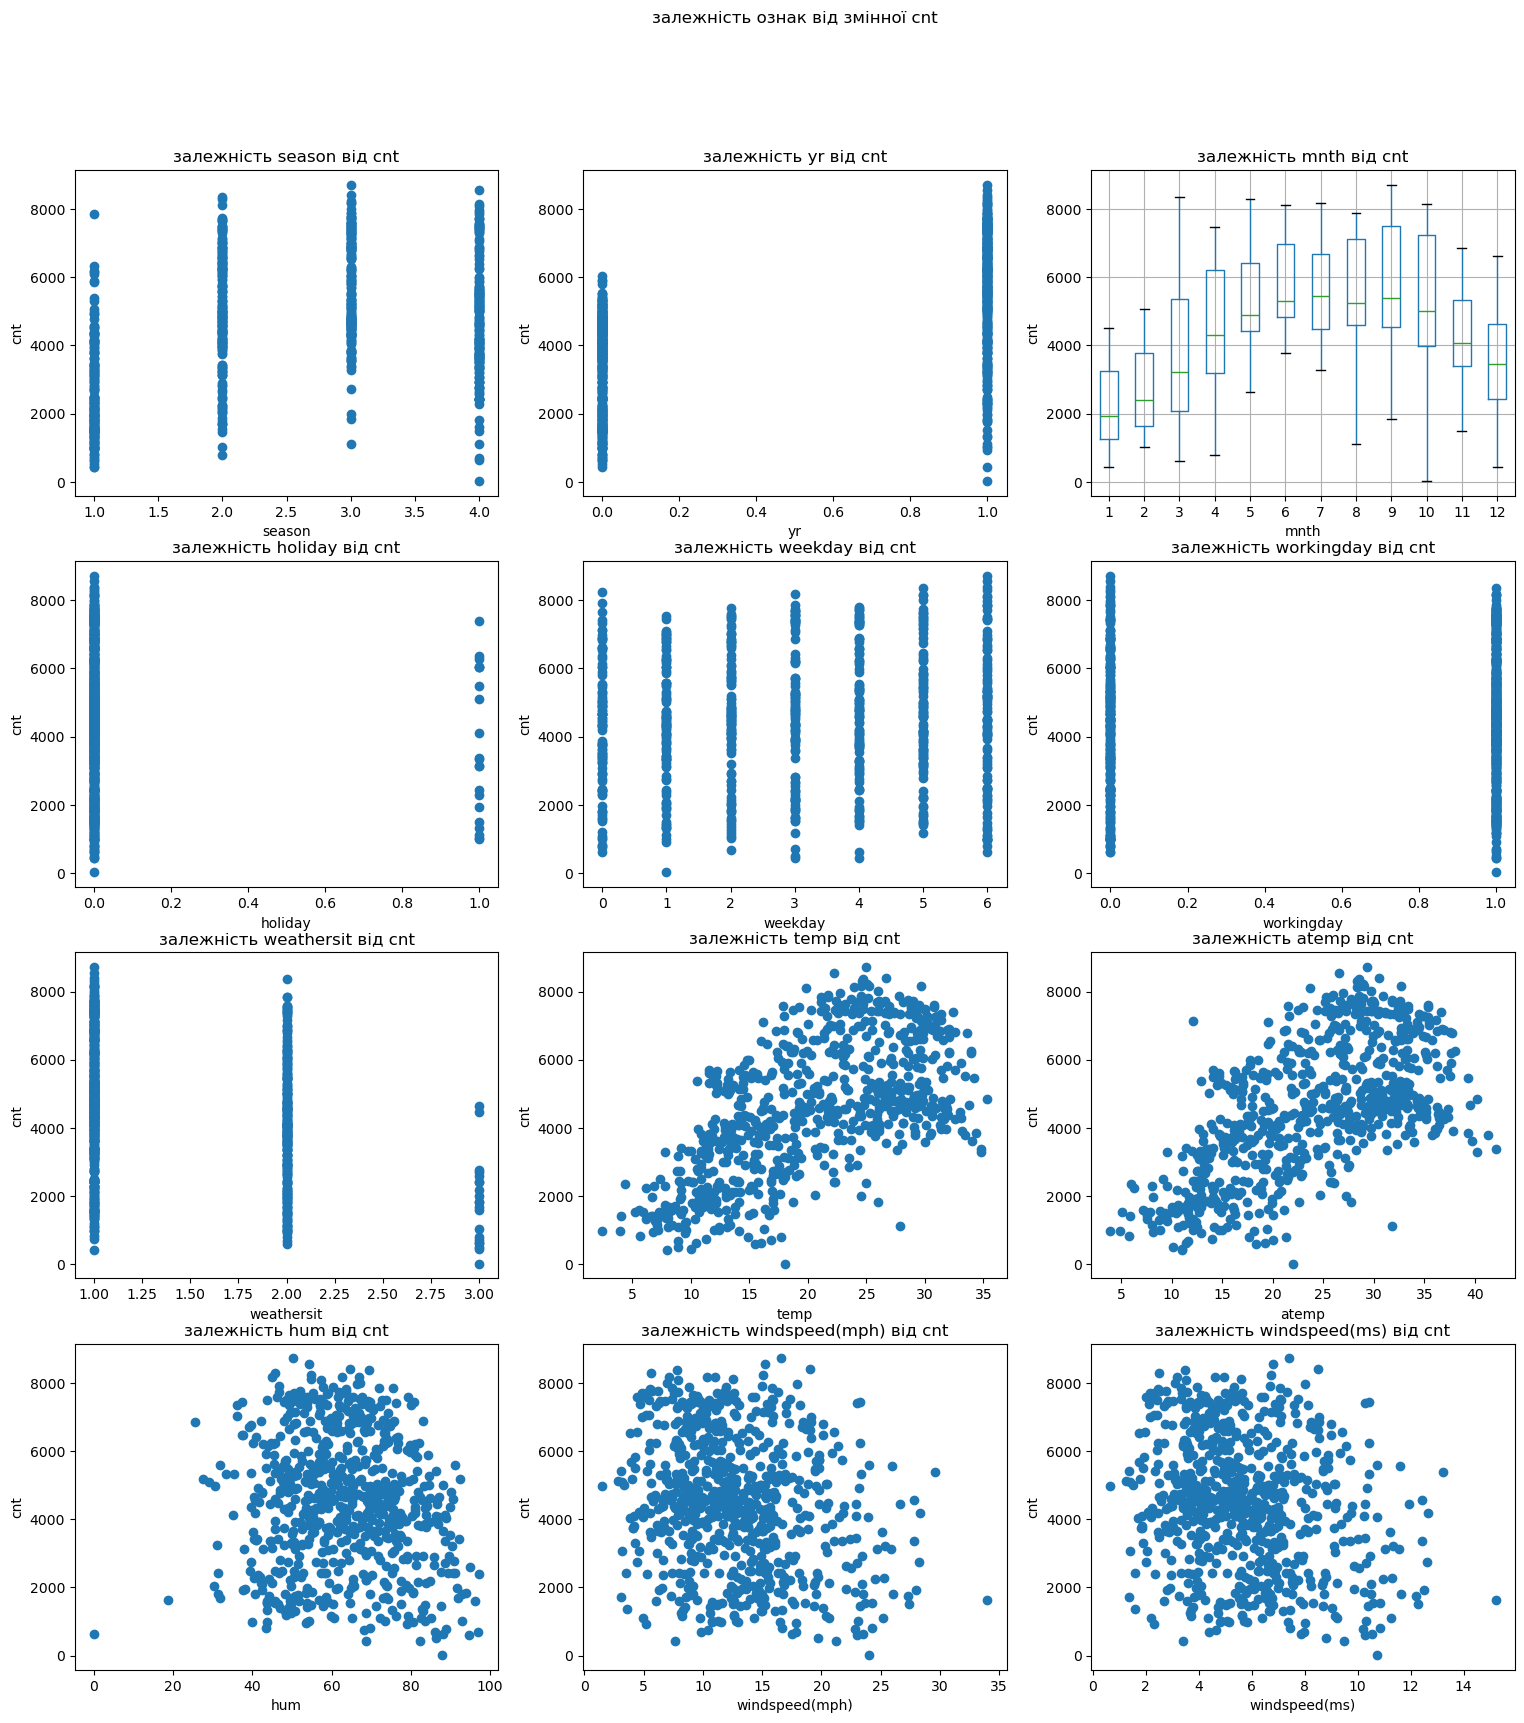

In [3]:
features = ["season", "yr","mnth","holiday","weekday","workingday","weathersit","temp","atemp","hum","windspeed(mph)","windspeed(ms)"]
target = "cnt"
fig, axs = plt.subplots(4, 3, figsize=(18, 20))
axs = axs.flatten() 
for i,feature in enumerate(features):
    if i == 2:
        df.boxplot(column='cnt', by='mnth', ax=axs[i])
    else:
        axs[i].scatter(df[feature],df[target],label=feature)
    axs[i].set_xlabel(f"{feature}")
    axs[i].set_ylabel(f"{target}")
    axs[i].set_title(f"залежність {feature} від {target}")
fig.suptitle("залежність ознак від змінної cnt") 
plt.show()

__Запитання:__
1. Яким є характер залежності кількості прокатів від місяця?
2. Вкажіть одну або дві ознаки, від яких кількість прокатів скоріше за все залежить лінійно.

Відповідь: 1. Характер залежності кількості прокатів від місяця є нелінійним, сезонним, з параболічними характеристиками. Починаючи з січня, медіана постійно зростає, досягаючи піку в липні, після чого поступово зменшується з серпня і продовжує цю тенденцію до грудня, де медіана приблизно дорівнює значенню березня. 
           2. temp та atemp - ознаки,  демонструють чітку лінійну залежність: зі зростанням температури кількість прокатів також зростає, що візуально проявляється як діагональна хмара точок на scatter plot, спрямована знизу-ліворуч до верхнього правого кута.

## Завдання 2

Давайте більш строго оцінимо рівень лінійної залежності між ознаками та цільовою змінною. Гарною мірою лінійної залежності між двома векторами є кореляція Пірсона. Нам уже доводилося мати з нею справу раніше. Для її обчислення в pandas можна використовувати методи датафрейму: corr і corrwith.

Порахуйте кореляції всіх ознак, окрім останньої, з останньою за допомогою методу `corrwith`.

In [4]:
for i in range(len(features)):
    corr = df[features[i]].corr(df[target],method="pearson")
    print(f"рівень лінійної залежності між {features[i]} та {target}: {corr}")

corr_with = df.corrwith(df[target])
print(f"{corr_with}")

рівень лінійної залежності між season та cnt: 0.40610037079863676
рівень лінійної залежності між yr та cnt: 0.5667097078680867
рівень лінійної залежності між mnth та cnt: 0.279977112219271
рівень лінійної залежності між holiday та cnt: -0.06834771589248403
рівень лінійної залежності між weekday та cnt: 0.06744341241063048
рівень лінійної залежності між workingday та cnt: 0.06115606306052067
рівень лінійної залежності між weathersit та cnt: -0.2973912388346637
рівень лінійної залежності між temp та cnt: 0.6274940090334924
рівень лінійної залежності між atemp та cnt: 0.6310656998491816
рівень лінійної залежності між hum та cnt: -0.10065856213715522
рівень лінійної залежності між windspeed(mph) та cnt: -0.23454499742167
рівень лінійної залежності між windspeed(ms) та cnt: -0.2345449974216893
season            0.406100
yr                0.566710
mnth              0.279977
holiday          -0.068348
weekday           0.067443
workingday        0.061156
weathersit       -0.297391
temp       

У вибірці є ознаки, що корелюють із цільовою, а отже, завдання можна розв'язувати лінійними методами.

За графіками видно, що деякі ознаки схожі між собою. Тому давайте також порахуємо кореляції між речовими ознаками.

## Завдання 3

Порахуйте попарні кореляції між ознаками temp, atemp, hum, windspeed(mph), windspeed(ms) і cnt
за допомогою методу corr:

In [5]:
# Put your code here
selected = ["temp","atemp","hum","windspeed(mph)","windspeed(ms)","cnt"]
corr = df[selected].corr()
corr

,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
temp,1.000000,0.991702,0.126963,-0.157944,-0.157944,0.627494
atemp,0.991702,1.000000,0.139988,-0.183643,-0.183643,0.631066
hum,0.126963,0.139988,1.000000,-0.248489,-0.248489,-0.100659
windspeed(mph),-0.157944,-0.183643,-0.248489,1.000000,1.000000,-0.234545
windspeed(ms),-0.157944,-0.183643,-0.248489,1.000000,1.000000,-0.234545
cnt,0.627494,0.631066,-0.100659,-0.234545,-0.234545,1.000000


На діагоналях, як і належить, стоять одиниці. Однак у матриці є ще дві пари сильно корелюючих стовпців: temp і atemp (корелюють за своєю природою) і два windspeed (тому що це просто переведення одних одиниць в інші). Далі ми побачимо, що цей факт негативно позначається на навчанні лінійної моделі.

Насамкінець подивимося середні ознак (метод mean), щоб оцінити масштаб ознак і частки 1 у бінарних ознак.

## Завдання 4

Виведіть середні ознак.

In [6]:
# Put your code here
df.mean()

season               2.496580
yr                   0.500684
mnth                 6.519836
holiday              0.028728
weekday              2.997264
workingday           0.683995
weathersit           1.395349
temp                20.310776
atemp               23.717699
hum                 62.789406
windspeed(mph)      12.762576
windspeed(ms)        5.705220
cnt               4504.348837
dtype: float64

Ознаки мають різний масштаб, отже, для подальшої роботи нам краще нормувати матрицю об'єкти-ознаки.

### Проблема перша: колінеарні ознаки

Отже, у наших даних одна ознака дублює іншу, і є ще дві дуже схожі. Звичайно, ми могли б одразу видалити дублікати, але давайте подивимося, як відбувалося б навчання моделі, якби ми не помітили цю проблему.

Для початку проведемо масштабування, або стандартизацію ознак: з кожної ознаки віднімемо її середнє і поділимо на стандартне відхилення. Це можна зробити за допомогою методу scale.

Крім того, необхідно перемішати вибірку, це буде потрібно для крос-валідації.

In [7]:
from sklearn.preprocessing import scale
from sklearn.utils import shuffle

In [8]:
df_shuffled = shuffle(df, random_state=42)
X = scale(df_shuffled[df_shuffled.columns[:-1]])
y = df_shuffled["cnt"]

Давайте навчимо лінійну регресію на наших даних і подивимося на ваги ознак.

In [9]:
from sklearn.linear_model import LinearRegression

## Завдання 5

Створіть об'єкт лінійного регресора, навчіть його на всіх даних і виведіть ваги моделі (ваги зберігаються у змінній `coef_` класу регресора). Можна виводити пари (назва ознаки, вага), скориставшись функцією `zip`, вбудованою в мову python. Назви ознак зберігаються у змінній `df.columns`.


In [10]:
# Put your code here
model = LinearRegression()
model.fit(X,y)
result = zip(df.columns[:-1],map(float,model.coef_))
list_result = list(result)
list_result.append(('w0', float(model.intercept_)))
# model_score = model.score(X,y)
# print(f'R^2 of model {model_score}')
list_result

[('season', 570.8693632797535),
 ('yr', 1021.9721595813337),
 ('mnth', -141.30453962011194),
 ('holiday', -86.75560531762187),
 ('weekday', 137.22411258841313),
 ('workingday', 56.39410303666908),
 ('weathersit', -330.23169353156516),
 ('temp', 367.46777184245224),
 ('atemp', 585.5635179675158),
 ('hum', -145.60536461872516),
 ('windspeed(mph)', 12461619843411.346),
 ('windspeed(ms)', -12461619843609.797),
 ('w0', 4504.354530261729)]

Ми бачимо, що ваги при лінійно-залежних ознаках за модулем значно більші, ніж при інших ознаках. Щоб зрозуміти, чому так сталося, згадаємо аналітичну формулу, за якою обчислюються ваги лінійної моделі в методі найменших квадратів:

$$w = (X^TX)^{-1} X^T y$$

Якщо в $X$ є колінеарні (лінійно-залежні) стовпці, матриця $X^TX$ стає виродженою, і формула перестає бути коректною. Чим більш залежні ознаки, тим менший визначник цієї матриці й тим гірша апроксимація $Xw \approx y$. Таку ситуацію називають _проблемою мультиколінеарності_.

З парою (temp, atemp) трохи менше корелюючих змінних такого не сталося, однак на практиці завжди варто уважно стежити за коефіцієнтами при схожих ознаках.

Для того щоб розв'язати проблему мультиколінеарності, потрібно скористатися регуляризатором. До оптимізуючого функціоналу додають $L_1$ або $L_2$ норму ваг, помножену на коефіцієнт регуляризації $\alpha$. У першому випадку метод називається Lasso, а у другому — Ridge.

### Завдання 6
Давайте спробуємо навчити лінійні моделі з $L_1$ і $L_2$-регуляризацією, а далі порівняємо їхні ваги. Навчіть регресори Ridge і Lasso з параметрами за замовчуванням і переконайтеся, що проблема з вагами вирішилась.

Навчіть лінійну модель з $L_1$-регуляризацією (клас Lasso) і виведіть ваги.

In [11]:
# Put your code here
from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=7.3)
lasso_model.fit(X,y)
lasso_result = zip(df.columns[:-1],map(float,lasso_model.coef_))
lasso_list = list(lasso_result)
lasso_list.append(('w0',float(lasso_model.intercept_)))
lasso_list
lasso_score = lasso_model.score(X,y)
print(f'R^2 {lasso_score}')
lasso_list

R^2 0.800003245560403


[('season', 524.6811460988798),
 ('yr', 1013.91534504461),
 ('mnth', -92.5798679983791),
 ('holiday', -82.55079714733125),
 ('weekday', 131.24499502575267),
 ('workingday', 50.6066609163608),
 ('weathersit', -330.08940534499675),
 ('temp', 369.22822611872505),
 ('atemp', 582.6361172944032),
 ('hum', -138.93549362908325),
 ('windspeed(mph)', -190.37624043614835),
 ('windspeed(ms)', -2.6514640877169215e-08),
 ('w0', 4504.3488372093025)]

Навчіть лінійну модель з $L_2$-регуляризацією (клас Ridge) і виведіть ваги.

In [12]:
# Put your code here
from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=13.7118).fit(X,y)
ridge_result = zip(df.columns[:-1],map(float,ridge_model.coef_))
ridge_list = list(ridge_result)
ridge_list.append(('w0',float(ridge_model.intercept_)))
ridge_score = ridge_model.score(X,y)
print(f"R^2 {ridge_score}")
ridge_list

R^2 0.8000000020104199


[('season', 530.2500792140244),
 ('yr', 1001.5643804034638),
 ('mnth', -102.16033906009993),
 ('holiday', -86.6310751807643),
 ('weekday', 134.5511028890335),
 ('workingday', 55.42965198004449),
 ('weathersit', -327.1340803417026),
 ('temp', 443.32123046263604),
 ('atemp', 506.9901891551451),
 ('hum', -147.04839751011082),
 ('windspeed(mph)', -100.4516492835766),
 ('windspeed(ms)', -100.45164928854211),
 ('w0', 4504.3488372093025)]

### Завдання 7

На відміну від $L_2$-регуляризації, $L_1$ обнуляє ваги при деяких ознаках. Давайте поспостерігаємо, як змінюються ваги зі збільшенням коефіцієнта регуляризації $\alpha$.

Для кожного значення коефіцієнта з `alphas` навчіть регресор `Lasso` і запишіть ваги у список `coefs_lasso`, а потім навчіть `Ridge` і запишіть ваги у список`coefs_ridge`. Конвертуйте отримані списки в `np.array`.

In [13]:
alphas = np.arange(1, 500, 50)

coefs_lasso = []
coefs_ridge = []

for alpha in alphas:
    lasso_model = Lasso(alpha=alpha).fit(X,y)
    coefs_lasso.append(lasso_model.coef_)
    ridge_model = Ridge(alpha=alpha).fit(X,y)
    coefs_ridge.append(ridge_model.coef_)

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

Проаналізуйте динаміку ваг при збільшенні параметра регуляризації:

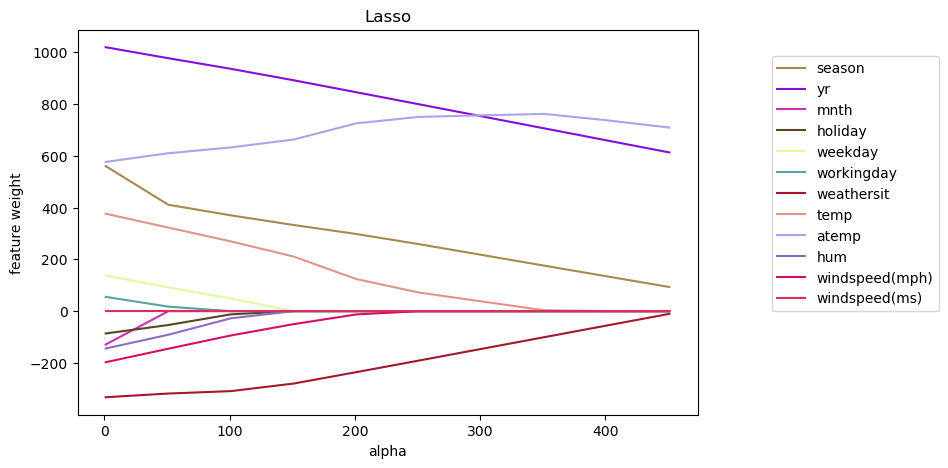

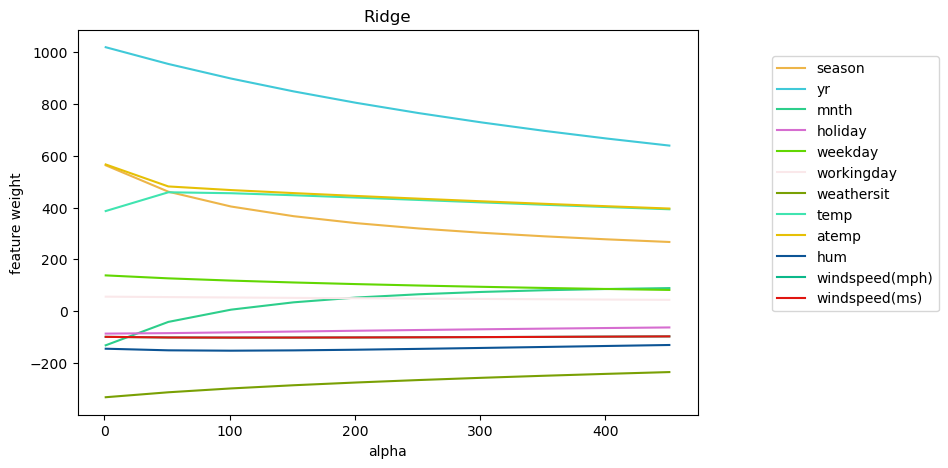

In [14]:
plt.figure(figsize=(8, 5))

for coef, feature in zip(coefs_lasso.T, df.columns):
    plt.plot(alphas, coef, label=feature, color=np.random.rand(3))

plt.legend(loc="upper right", bbox_to_anchor=(1.4, 0.95))
plt.xlabel("alpha")
plt.ylabel("feature weight")
plt.title("Lasso")

plt.figure(figsize=(8, 5))
for coef, feature in zip(coefs_ridge.T, df.columns):
    plt.plot(alphas, coef, label=feature, color=np.random.rand(3))

plt.legend(loc="upper right", bbox_to_anchor=(1.4, 0.95))
plt.xlabel("alpha")
plt.ylabel("feature weight")
plt.title("Ridge")

plt.show()

Проаналізуйте графіки та дайте відповіді на такі запитання.

1. Який регуляризатор (Ridge або Lasso) агресивніше зменшує ваги при одному й тому самому alpha?
1. Що станеться з вагами Lasso, якщо alpha зробити дуже великим? Поясніть, чому так відбувається.
1. Чи можна стверджувати, що `Lasso` виключає одну з ознак `windspeed` при будь-якому значенні `alpha > 0`? А Ridge? Вважається, що регуляризатор виключає ознаку, якщо коефіцієнт при ньому менший $10^{-3}$.
1. Який із регуляризаторів підійде для відбору неінформативних ознак?

Відповідь: 1. регуляризатор Lasso агресивніше зменшує ваги порівняно з Ridge у випадку використання однакових значень альфи. 
           2. Якщо alpha буде великою, деякі вагові коефіцієнти Лассо будуть дорівнювати 0, оскільки Lasso регуляризатор здійснює відбір ознак і дозволяє використовувати в моделі не всі ознаки, а лише найважливіші з них.
           3. Через мультиколінеарність між windspeed(mph) та windspeed(ms) L1-регуляризація повністю занулює коефіцієнт при windspeed(ms) для будь-якого alpha > 0. Його вага стає рівною 0, що менше за 10^-3, отже ознака виключається. L2-регуляризація лише зменшує ваги скорельованих ознак, розподіляючи навантаження між ними, але не занулює їх. На графіку видно, що ваги обох ознак швидкості вітру залишаються ненульовими і за модулем значно більшими за 10^-3, тому Ridge їх не виключає.
           4. Для відбору неінформативних ознак підходить Lasso, тому що має властивість зануляти коефіцієнти при неінформативних або мультиколінеарних ознаках, автоматично виключаючи їх з моделі.

### Завдання 8

Далі будемо працювати з `Lasso`.

Отже, ми бачимо, що при зміні alpha модель по-різному підбирає коефіцієнти ознак. Нам потрібно вибрати найкраще alpha.

Для цього, по-перше, нам потрібна метрика якості. Будемо використовувати як метрику сам оптимізований функціонал методу найменших квадратів, тобто `Mean Square Error`.

По-друге, потрібно зрозуміти, на яких даних цю метрику рахувати. Не можна вибирати `alpha` за значенням MSE на навчальній вибірці, тому що тоді ми не зможемо оцінити, як модель буде робити передбачення на нових для неї даних. Якщо ми виберемо одне розбиття вибірки на навчальну та тестову (це називається holdout), то налаштуємося на конкретні "нові" дані, і знову можемо перенавчитися. Тому будемо робити декілька розбиттів вибірки, на кожному пробувати різні значення alpha, а потім усереднювати MSE. Найзручніше робити такі розбиття крос-валідацією, тобто розділити вибірку на $K$ частин, і кожного разу брати одну з них як тестову, а з блоків, що залишилися, складати навчальну вибірку.

Робити крос-валідацію для регресії в sklearn зовсім просто: для цього є спеціальний регресор, __LassoCV__, який бере на вхід список із alpha і для кожного з них обчислює MSE на крос-валідації. Після навчання (якщо залишити параметр cv=3 за замовчуванням) регресор буде містити змінну __mse\_path\___, матрицю розміру len(alpha) x k, k = 3 (число блоків у крос-валідації), що містить значення MSE на тесті для відповідних запусків. Крім того, у змінній alpha\_ буде зберігатися вибране значення параметра регуляризації, а в coef\_, традиційно, навчені ваги, що відповідають цьому alpha_.

Зверніть увагу, що регресор може змінювати порядок, у якому він проходить по alphas; для зіставлення з матрицею MSE краще використовувати змінну регресора alphas_.

Навчіть регресор `LassoCV` на всіх параметрах регуляризації з alpha. Побудуйте графік _усередненого_ за рядками `MSE` в залежності від `alpha` (використовуйте для цього функцію `create_plot`).

Виведіть вибране `alpha`, а також пари "ознака-коефіцієнт" для навченого вектора коефіцієнтів.

In [15]:
def create_plot(data, title, xlabel, ylabel, figsize=None):
    size = figsize or (15, 5)
    plt.figure(figsize=size)

    x = list(map(lambda e: e[0], data))
    y = list(map(lambda e: e[1], data))
    plt.plot(x, y)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.grid()
    plt.show()

Вибране alpha 6 

season 532.0189828413535
yr 1015.0602226430592
mnth -100.03952614356622
holiday -83.29395987529924
weekday 132.50446549095787
workingday 51.55708561407394
weathersit -330.55985673998157
temp 370.679855030032
atemp 581.3969310654999
hum -140.0074055006885
windspeed(mph) -191.77140847135084
windspeed(ms) -2.6854222061742536e-08


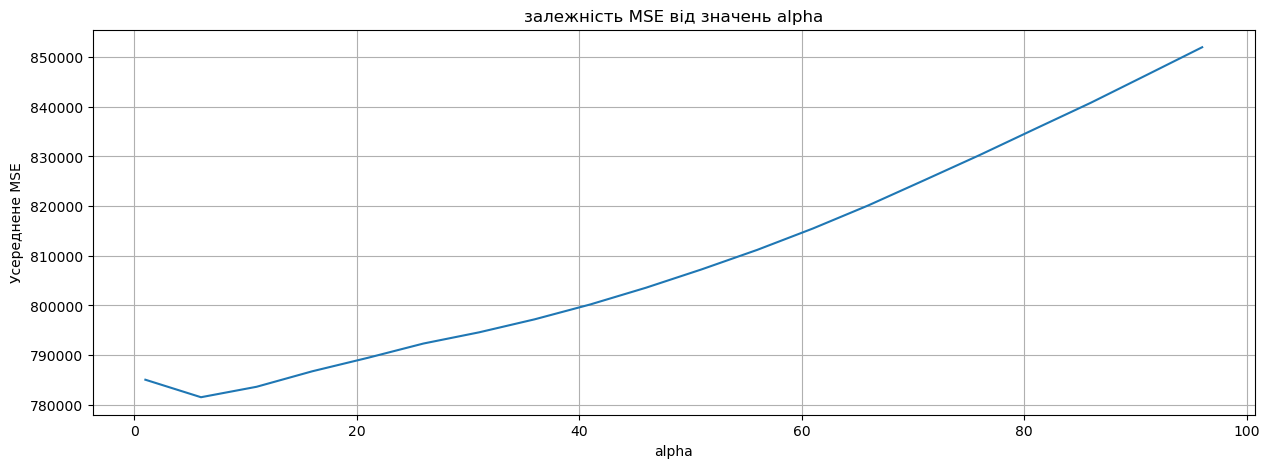

In [16]:
from sklearn.linear_model import LassoCV
title = "залежність MSE від значень alpha"

alphas = np.arange(1, 100, 5)
regressor = LassoCV(alphas=alphas,cv=3)
regressor.fit(X,y)
print('Вибране alpha', regressor.alpha_, '\n')
for f,c in zip(df.columns,regressor.coef_):
    print(f,c)
    
mse_scores = np.mean(regressor.mse_path_, axis=1)
data_for_plot = list(zip(regressor.alphas_, mse_scores))
create_plot(data_for_plot,title, 'alpha', 'Усереднене MSE')

Отже, ми вибрали певний параметр регуляризації. Давайте подивимося, які б ми вибирали alpha, якби ділили вибірку лише один раз на навчальну та тестову, тобто розглянемо траєкторії MSE, що відповідають окремим блокам вибірки.

### Завдання 9

Виведіть значення `alpha`, що відповідають мінімумам `MSE` на кожному розбитті (тобто за стовпцями).
На трьох окремих графіках візуалізуйте стовпці `mse_path_`.


Розбиття 1: оптимальне alpha = 6
Розбиття 2: оптимальне alpha = 1
Розбиття 3: оптимальне alpha = 51


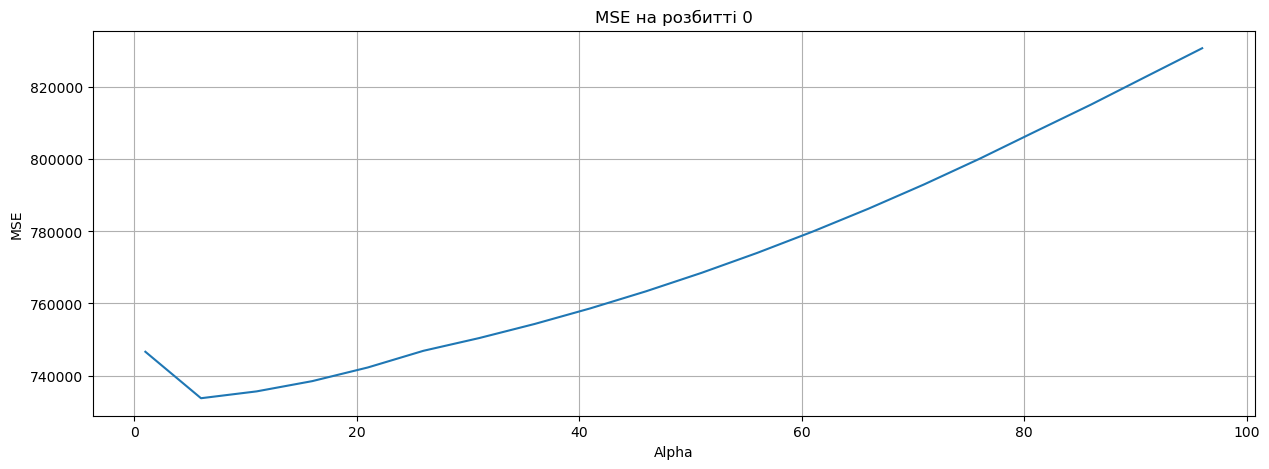

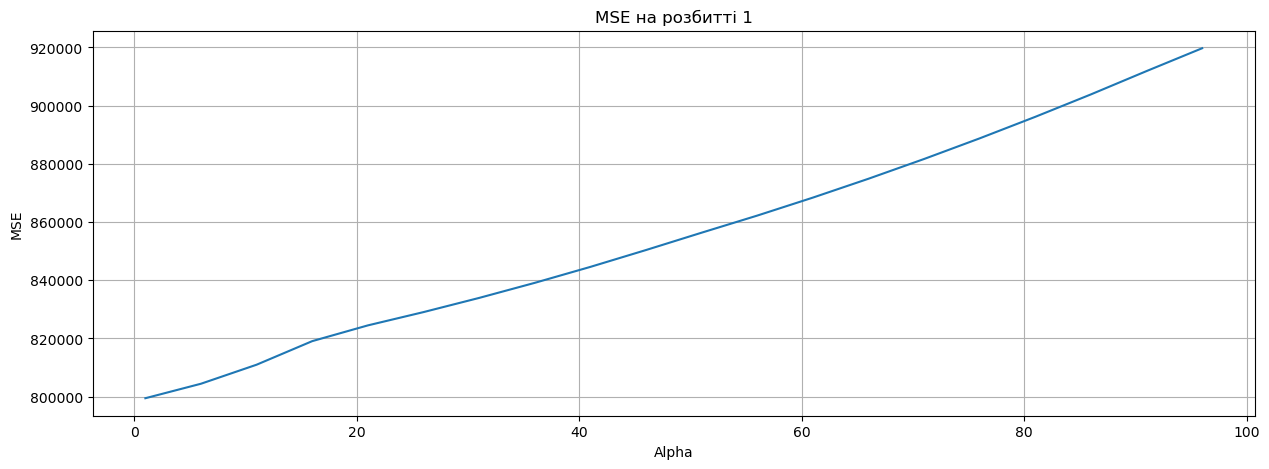

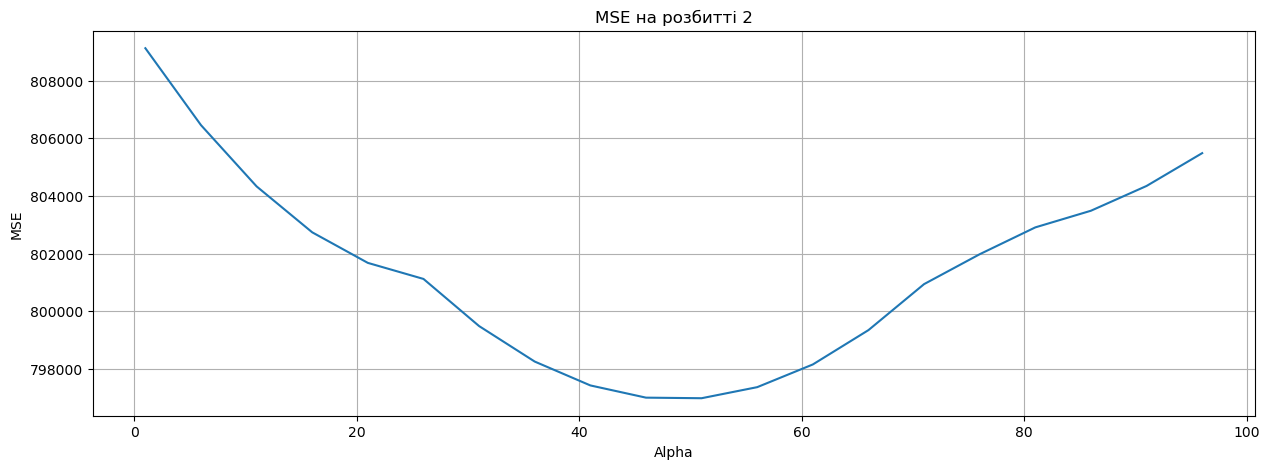

In [17]:
# Put your code here
regressor.mse_path_.min(axis=1)

for i in range(3):
    list_mse = regressor.mse_path_[:,i]
    alphas_mse_pairs = zip(regressor.alphas_, list_mse)

    best_alpha = min(alphas_mse_pairs, key=lambda pair: pair[1])[0]
    print(f"Розбиття {i + 1}: оптимальне alpha = {best_alpha}")
    
for i in range(3):
    data_fold = list(zip(regressor.alphas_, regressor.mse_path_[:, i]))
    create_plot(data_fold, title=f"MSE на розбитті {i}", xlabel="Alpha", ylabel="MSE")

На кожному розбитті оптимальне значення `alpha` своє, і йому відповідає велике MSE на інших розбиттях. Виходить, що ми налаштовуємося на конкретні навчальні та контрольні вибірки. При виборі `alpha` на крос-валідації ми вибираємо дещо "середнє", що даватиме прийнятне значення метрики на різних розбиттях вибірки.

### Завдання 10

Нарешті, як прийнято в аналізі даних, давайте проінтерпретуємо результат. Дайте відповіді на наступні запитання.

#### Запитання 1

В останній навченій моделі виберіть 4 ознаки з найбільшими (позитивними) коефіцієнтами (і випишіть їх), подивіться на візуалізації залежностей `cnt` від цих ознак, які ми зображали у блоці "Ознайомлення з даними". Чи видно зростаючу лінійну залежність `cnt` від цих ознак за графіками? Чи логічно стверджувати (виходячи зі здорового глузду), що чим більше значення цих ознак, тим більше людей захочуть взяти велосипеди?

__Відповідь:__

Найбільші позитивні коефіцієнти мають yr (k = 1015.06), atemp (k = 581.40), season (k = 532.02) та temp (k = 370.68). Ознаки temp та atemp - мультиколінеарні, на графіках чітко видно безперервну зростаючу лінійну залежність cnt від цих ознак. yr та season - це дискретні ознаки, тому класичну лінійну лінію побачити важко. Проте видно загальний тренд зростання попиту при переході від 0 до 1 (yr) та від 1 до 3 (season).Логічне обґрунтування: Зі здорового глузду — ні, це лінійне спрощення моделі, яке працює не для всього:yr — ТАК: Перехід від 0 до 1 відображає природний розвиток бізнесу та зростання популярності сервісу з часом. season (Сезон) — НІ: Ознака кодується від 1 (зима) до 4 (осінь). Осінь (4) холодніша за літо (3), тому попит на кроці  4 падає, що суперечить лінійній логіці моделі. temp та atemp — ТАК, але до певної межі: Тепла погода збільшує попит, але екстремальна спека його знижує. На графіках видно, як при максимальних температурах хмара точок загинається вниз.

#### Запитання 2

Виберіть 3 ознаки з найбільшими за модулем негативними коефіцієнтами (і випишіть їх), подивіться на відповідні візуалізації. Чи видно лінійну залежність, що зменшується? Чи логічно стверджувати, що чим більша величина цих ознак, тим менше людей захочуть взяти велосипеди?

__Відповідь:__

Три ознаки з найбільшими негативними коефіцієнтами — це weathersit (k = -330.55985673998157), windspeed(mph) (k = -191.77140847135084) та hum (k = -140.0074055006885). Дискретна ознака weathersit не має безперервної лінії, але щільність точок очікувано падає при погіршенні погоди від 1 до 3. Натомість hum та windspeed(mph) мають чіткий лінійний аспект падіння з середини графіків: для вологості спад верхньої межі попиту починається після точки X ≈ 45, Y ≈ 8100 до X ≈ 95, Y ≈ 500, а для швидкості вітру — від піка в районі X ≈ 5, Y ≈ 8000 і постійно знижується до x ≈  25, Y ≈ 400. Логічне обґрунтування: Зі здорового глузду твердження логічне, адже чим більші значення ознак (вища вологість, сильніший вітер, гірша погода), тим менше людей захочуть взяти велосипеди через дискомфорт, що й відображають негативні коефіцієнти моделі. Водночас математичне зростання самих ваг (-140 до -40, ближче до нуля) означає послаблення цього негативного штрафу, через що прогнозована кількість оренд навпаки збільшуватиметься.

#### Запитання 3

Випишіть ознаки з коефіцієнтами, близькими до нуля (< 1e-3). Як ви думаєте, чому модель виключила їх із моделі (знову подивіться на графіки)? Чи правда, що вони ніяк не впливають на попит на велосипеди?

__Відповідь:__

windspeed(ms) (k = -2.6854222061742536e-08) є однією ознакою у якої коефіцієнт < 1е-3. Модель Lasso виключила її через високу колінеарність (взаємну пропорційність) з ознакою windspeed(mph). Твердження, що вона взагалі не впливає на попит, є неправильним, адже графіки обох ознак абсолютно ідентичні й демонструють сильний вплив на cnt. Проте для алгоритму ця інформація є дублюючою, 
тому Lasso занулило вагу windspeed(ms), щоб уникнути нестабільності моделі, повністю переклавши весь фізичний зв'язок швидкості вітру на коефіцієнт ознаки windspeed(mph)

### Висновок
Отже, ми подивилися, як можна стежити за адекватністю лінійної моделі, як відбирати ознаки і як грамотно, за можливості не налаштовуючись на якусь конкретну порцію даних, підбирати коефіцієнт регуляризації.

Варто зазначити, що за допомогою крос-валідації зручно підбирати лише невелику кількість параметрів. (1, 2, максимум 3), тому що для кожної допустимої їх комбінації нам доводиться декілька разів навчати модель. Такий процес займає багато часу, особливо якщо треба навчатися на великих обсягах даних.